!pip install rawpy
!pip install imageio
!pip install matplotlib
!pip install scikit-learn
!pip install pandas

In [1]:
import rawpy
import imageio
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display
import PIL as Image
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import sklearn.metrics as metrics

from pathlib import Path
import joblib


In [2]:
def pre_summary(long,k):
    central_moments = np.array(list(map(lambda n :np.mean((long - np.mean(long))**n)/(np.std(long)**n),range(2,k+1))))
    raw_moments = np.array(list(map(lambda n :np.mean(long**n)/(np.std(long)**n),range(1,k+1))))
    extreme = np.array([max(long)-min(long),max(long)-raw_moments[0],min(long)-raw_moments[0]])
    summary = np.concatenate((central_moments,raw_moments,extreme),axis = 0)
    
    return(summary)

def image_summary(image, k = 3):
    pixels = image.flatten().tolist() # flattens the image into a long list
    reds   = np.array(pixels[0::3])
    greens = np.array(pixels[1::3]) # seperates each color into its own list
    blues  = np.array(pixels[2::3])
    red_summary = pre_summary(reds, k)
    blue_summary = pre_summary(blues, k)
    green_summary = pre_summary(greens, k)
    summary = np.concatenate((red_summary,blue_summary,green_summary),axis = 0) # returns the 3*k moments
    
    return(summary)


In [3]:
def grey_if_true(image, grey):
    if not grey:
        return image
    elif grey:
        grey_single = image.mean(axis=2, keepdims=True)
        grey_3channel = np.repeat(grey_single, 3, axis=2).astype(image.dtype)
        return grey_3channel


In [4]:
def show_predictions(folder, filename, model ,slice_factor = 1, size = 224, M=3):
    with rawpy.imread(f"{folder}{filename}.CR2") as raw:
        rgb = raw.postprocess(use_camera_wb=True, no_auto_bright=False, bright=1.0)

    # SLICING THE IMAGE, just downscaling
    rgb = rgb[::slice_factor, ::slice_factor]
            
    vertical_slices, horizontal_slices = get_slices(rgb,size)
    K,N = (len(vertical_slices),len(horizontal_slices))
    
    k = 0
    long_stack = []
    while k<(K-1):
        n = 0

        wide_stack = []
        while n<(N-1):
            im = rgb[vertical_slices[k],horizontal_slices[n]]
            summary = image_summary(im, k = M)
            out = grey_if_true(im,not bool(model.predict([summary])[0]))
            wide_stack.append(out)
            n+=1
        long_stack.append(np.concatenate(wide_stack,axis = 1))
        k+=1
    return(np.concatenate(long_stack, axis = 0))
    


In [5]:
def get_slices(rgb,size):
    # DEFINES THE SUBSETS
    height = rgb.shape[0]
    width = rgb.shape[1]

    vertical_slices = []
    horizontal_slices = []

    K = height//size + 1
    for k in range(K):
        t = slice(k*size,min([(k+1)*size,height-1]))
        vertical_slices.append(t)

    N = width//size + 1
    for n in range(N):
        t = slice(n*size,min([(n+1)*size,width-1]))
        horizontal_slices.append(t)
        
    return (vertical_slices,horizontal_slices)


# Labeling the Images
This function allows the user to label subimages of an image that is imported.
- `size` allows the user to set the number of pixels of the the sidelength of the square subimage.
- `slice_factor` "zooms in" by crudely replaceing every n by n square with 1 of the pixels within it. This is used so that the images can be shrunken easily and speeds up the labeling process.
When labeling the user enters:
- `y` if empty
- `n` if not empty
- `b` to go back and delete the last label if there was a mistake.
- `c` to stop labeling early

This function is designed to be run on a single image. We will need to use a for-loop to go through all of the images for our NB training data. Then we will need to combine all of the saved files into one large npz.

There are a couple of assumptions I have here. This may be something we should talk about.

1. I'm not messing with the model = None part. I think that will come into play when we get to training the labeling CNN.
2. We will likely need a modified label subimages function when we train the labeling CNN. (The inputs are different. When we are training the labeling CNN, we should already have sliced or chunked the images.)
3. The functionality of the c option doesn't feel great. It seems like it would be easy to 

In [32]:
import os
import rawpy
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

def label_subimages_NB(folder, filename, size=224, slice_factor=1):
    raw_path = os.path.join(folder, f"{filename}.CR2")
    with rawpy.imread(raw_path) as raw:
        rgb = raw.postprocess(use_camera_wb=True, bright=1.0)

    # Downsample if needed
    rgb = rgb[::slice_factor, ::slice_factor]
    
    vertical_slices, horizontal_slices = get_slices(rgb, size)
    
    all_coords = list(product(range(len(vertical_slices) - 1), 
                             range(len(horizontal_slices) - 1)))
    
    images = []
    labels = []
    i = 0  #This was originally a double while loop. The break function for 'c' was not getting us out of both while loops. I've changed it to a single while loop.


    while i < len(all_coords):
        row_idx, col_idx = all_coords[i]
        im = rgb[vertical_slices[row_idx], horizontal_slices[col_idx]]
        
        # Update the UI
        plt.axis("off")
        plt.imshow(im)
        plt.show()

        user_input = input(f"[{i+1}] Is this empty? (y= yes, n= no, b=back, c=exit): ").lower()

        if user_input == 'c':
            break # Only one loop to break now!
        
        elif user_input in ['y', 'n']:
            images.append(im)
            labels.append(1 if user_input == 'y' else 0)
            i += 1 # Move to the next tile
            
        elif user_input == 'b':
            # The goal is to remove the last appended value for images and labels.
            if i > 0:
                i -= 1 # Step the pointer back
                images.pop() # Remove last saved image
                labels.pop() # Remove last saved label
            else:
                print("Already at the first image.")
        else:
            print("Invalid input. Please use y, n, b, or c.")


    # save an npz file that has a column of subimages and then a column of their labels.
    sub_images = np.stack(images, axis = 0)
    sub_image_labels = np.array(labels)
    print("done")


    np.savez(fr"C:\Users\dwalk\Documents\Session1\LabeledSubimages\{filename}.npz", images=sub_images, labels=sub_image_labels)

## Running the image labeling 

In [33]:
raw_image_source = r"C:\Users\dwalk\Documents\Session1" 
folder_path = Path(raw_image_source)

files = [f.name[:-4] for f in folder_path.iterdir() if(f.is_file() and f.name[-4:] == '.CR2')]


5B7A9563


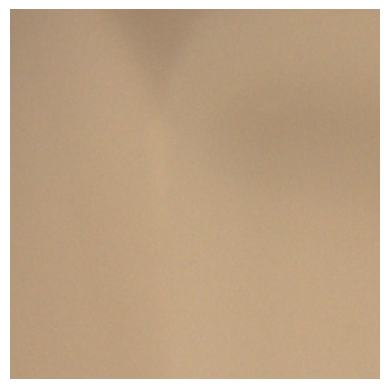

In [ ]:
for file in files:
    print(file)
    label_subimages_NB(raw_image_source,file,size = 224,slice_factor = 2)
    
    
    # label until done, press c to stop and save

# Saving and Organizing the Data

- Each time the labeling function is run, it makes a new npz folder for that specific image.
- All of the sessions of labeling are combined here into one big npz folder. using_model

In [ ]:
labeled_image_source = r"C:\Users\dwalk\Documents\full_data.npz"
folder_path = Path(labeled_image_source)
labeled = [f.name[:-4] for f in folder_path.iterdir() if (f.is_file() and f.name[-4:]=='.npz')]
# COMBINES THE LABELED DATA INTO ONE FILE


In [ ]:
labeled_image_source = r"C:\Users\dwalk\Documents\full_data.npz"
datasets = np.load(labeled_image_source)
print(type(datasets))
print(datasets.files)
print(datasets['images'])
print(datasets.x)

In [ ]:
#labeled = ["5B7A9568","5B7A9558","5B7A9562"]
#datasets = [np.load(f'{labeled_image_source}{x}.npz') for x in labeled]
labeled_image_source = r"C:\Users\dwalk\Documents\full_data.npz"
datasets = np.load(labeled_image_source)
images = [datasets['images'] for dataset in datasets]
labels = [datasets['labels'] for dataset in datasets]
images = np.concatenate(images,axis = 0)
labels = np.concatenate(labels,axis = 0)

# SAVES THE FILE
np.savez('full_data.npz', images=images, labels=labels)

In [ ]:
# READS THE COMBINED FILE 
data = np.load('full_data.npz')
plt.imshow(data['images'][np.where(data['labels'] !=0)[0][0]])
data['images'].shape

# Naive Bayes
- I flattened the images into lists of color values so [r1,g1,b1,r2,g2,b2,...]
- then seperated by color into 3 lists.
- In order to have a scalable way of using summary statistics I just made a function that would take the first k raw moments and central moments and the difference between the minimum value and maximum value for each of the colors. 
- k is the number of moments to take so you end up with 3k features for naive bayes.
- It seemed like k higher than 3 made the naive model worse.


In [ ]:
M = 3 # number of raw moments to use as predictors

summarylist = np.array([image_summary(x, k = M) for x in data['images']]) #I changed k = 3 from k = M.

original_indices = np.arange(len(summarylist))
X_train, X_test, y_train, y_test, index_train, index_test= train_test_split(summarylist, data['labels'],original_indices, test_size=0.2)
model = GaussianNB()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

## Testing the Model
- I saved the indexes from the original data of the test set.
- This allowed me to look at the image of the errors.
- What I noticed was that every time it would make a mistake it would be on the corner or the edge of the box.
- Probabily because of the variance in light.
- This is pretty good though given that I only labeled 3 images.

In [ ]:

predictions = model.predict(X_train)
con_mat = metrics.confusion_matrix(y_train,predictions)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=model.classes_)

disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:

predictions = model.predict(X_test)

con_mat = metrics.confusion_matrix(y_test,predictions)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=model.classes_)

disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
# The indexes of the errors in the test set.
errors = np.where(y_test != predictions)
print(errors[0].shape)

In [ ]:
place = errors[0][0]
plt.imshow(data['images'][index_test[place]])
print(f" predicted:{predictions[place]}\ntrue value:{data['labels'][index_test[place]]}")

In [ ]:
first_image = show_predictions("data/Nov12/",files[11],model,size = 224,slice_factor = 2,M=M)
plt.axis(False)
plt.imshow(first_image)

In [ ]:
 # save the naive bayes model

joblib.dump(model, 'naive_bayes_model.pkl')

In [ ]:
# import the naive bayes model

model = joblib.load('naive_bayes_model.pkl')

In [ ]:
#labeled = ["5B7A9568","5B7A9558","5B7A9562"]
#datasets = [np.load(f'{labeled_image_source}{x}.npz') for x in labeled]
labeled_image_source = r"C:\Users\dwalk\Documents\full_data.npz"
datasets = np.load(labeled_image_source)


In [ ]:
#!pip install pandas
import pandas as pd
df = pd.DataFrame({
    'data': list(datasets['images']),  # Wrap in list if you want one row per array
    'labels': datasets['labels']
})

# Apply the mask to the whole dataframe
filtered_df = df[df['labels'] != 0].copy()

# Now you can access both columns
print(f"Remaining rows: {len(filtered_df)}")
print(filtered_df.head())

# Reset the index to be sequential
filtered_df = filtered_df.reset_index(drop=True)

# Check the results
print(filtered_df.head())
import numpy as np

# 1. Extract the images and stack them into a single 4D array
# We use .values to get the series and np.stack to combine the individual arrays
filtered_images = np.stack(filtered_df['data'].values)

# 2. Extract the labels as a simple 1D array
filtered_labels = filtered_df['labels'].values

# 3. Save to an .npz file
save_path = 'filteredTest.npz'
np.savez_compressed(save_path, images=filtered_images, labels=filtered_labels)

print(f"Saved! Shape: {filtered_images.shape}")


In [ ]:
print(filtered['labels'])
np.savez("filtered.npz", **{col: filtered[col].values for col in df.columns})
